# Clustering Assignments

## 1. K-Means Clustering

In [4]:
# 1. Read in the cereal.csv file
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv(r'C:\BIT_Data_analyst\06_machine learning\07_lesson\cereal.csv')

In [5]:
# 2. Prep the data by dropping the name and manufacturer columns: aka only keep the numeric columns
df_numeric = df.drop(columns=['Cereal Name', 'Manufacturer'])

In [6]:
# 3. Fit a K-Means Clustering model with 2 clusters
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
df_numeric['cluster_2'] = kmeans_2.fit_predict(df_numeric)

In [7]:
# 4. Interpret the cluster centers
centers_2 = pd.DataFrame(kmeans_2.cluster_centers_, columns=df_numeric.columns[:-1])
print("K-Means (2 clusters) Centers:\n", centers_2)

K-Means (2 clusters) Centers:
      Calories  Protein (g)       Fat    Sugars  Vitamins and Minerals
0  104.558824     2.485294  0.955882  6.808824              22.058824
1  116.666667     2.666667  0.833333  6.333333             100.000000


## 2. Inertia Plot

In [11]:
# 1. Write a loop to fit K-Means Clustering models with 2 to 15 clusters
inertia = []
K = range(2, 16)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_numeric.drop(columns=['cluster_2']))
    inertia.append(km.inertia_)


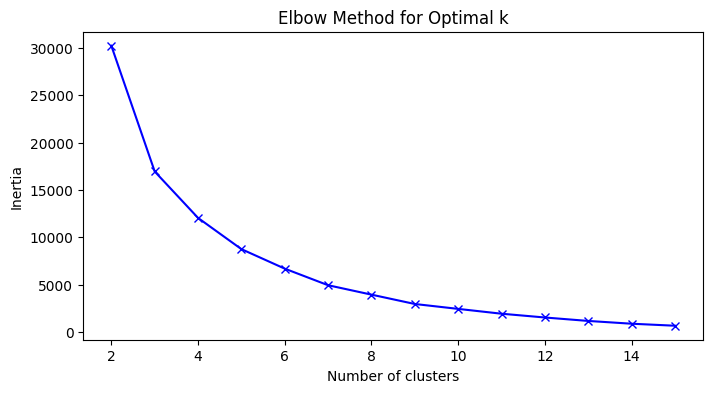

In [12]:
# 2. Create a plot with the number of clusters on the x-axis and the inertia on the y-axis
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [18]:
original_cols = ['Calories', 'Protein (g)', 'Fat', 'Sugars', 'Vitamins and Minerals']

In [19]:
# 3. Identify the elbow of the plot
elbow_k = 5 
km_elbow = KMeans(n_clusters=elbow_k, random_state=42, n_init=10)
# Fit modelį tik ant 5 originalių stulpelių
km_elbow.fit(df[original_cols])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [20]:
# 4. Fit a K-Means Clustering model on the specific number of clusters at the elbow
centers_elbow = pd.DataFrame(km_elbow.cluster_centers_, columns=original_cols)

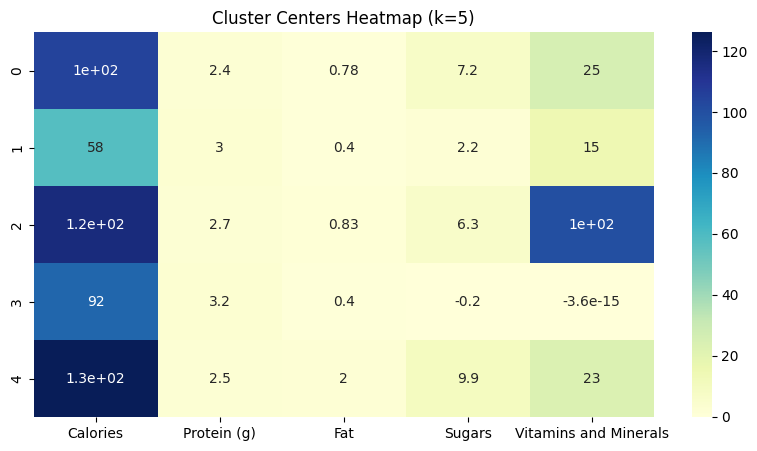

In [21]:
# 5. Interpret the cluster centers using a heat map
plt.figure(figsize=(10, 5))
sns.heatmap(centers_elbow, annot=True, cmap='YlGnBu')
plt.title(f'Cluster Centers Heatmap (k={elbow_k})')
plt.show()

## 3. Tune the K-Means Model

In [ ]:
# 1. Remove the ”Fat” column


In [ ]:
# 2. Standardize the remaining columns


In [ ]:
# 3a. Write a loop to fit K-Means Clustering models with 2 to 15 clusters


In [ ]:
# 3b. Create a plot with the number of clusters on the x-axis and the inertia on the y-axis


In [ ]:
# 3c. Identify the elbow of the plot


In [ ]:
# 3d. Fit a K-Means Clustering model on the specific number of clusters at the elbow


In [ ]:
# 3e. Interpret the cluster centers using a heat map


## 4. Select the Best K-Means Model

In [ ]:
# 1. Label each row in your original data set with a cluster name from the unstandardized data model and a cluster name from standardized data model


In [ ]:
# 2. Look at the number of cereals that fall into each cluster


In [ ]:
# 3. Decide on the best model for our client


In [ ]:
# 4. Recommend a specific number of displays


In [ ]:
# 5. Suggest a few cereals that should be shown in each display


## 5. Hierarchical Clustering

In [ ]:
# 1. Create a dendrogram using the 5 numeric fields of the cereal data set


In [ ]:
# 2. Visually identify the ”best” number of clusters and adjust the color_threshold


In [ ]:
# 3. Create a dendrogram using the 4 numeric, standardized fields (excluding “Fat”) of the cereal data set


In [ ]:
# 4. Visually identify the ”best” number of clusters and adjust the color_threshold


In [ ]:
# 5. Fit an agglomerative clustering model on the scaled data set with four clusters and view the labels


In [ ]:
# 6. Create a cluster map of the “best” results and interpret the clusters


## 6. DBSCAN

In [ ]:
# 1. Copy over the function that loops through multiple eps and min_samples values to fit multiple DBSCAN models


In [ ]:
# 2. Apply the function on both the original and standardized data sets


In [ ]:
# 3. Find the highest silhouette score and note down the eps and min_samples values


In [ ]:
# 4. Fit a final DBSCAN model with those eps and min_samples values and view the labels
